# 🧠 Notebook 4 — Hidden Patterns & Trading Strategies
Identify actionable insights: trader archetypes, optimal entry zones, leverage discipline.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


CANDIDATE_ROOTS = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next(
    (path for path in CANDIDATE_ROOTS if (path / "src" / "helpers.py").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate the project root containing src/helpers.py")

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from helpers import COLORS, REPORTS_DIR, ZONE_ORDER, load_processed, matched_sentiment, save_fig, style_axes

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

fg, tr, merged = load_processed()
matched = matched_sentiment(merged)
analysis = matched[matched["closedPnL"].notna()].copy() if "closedPnL" in matched.columns else matched.copy()
print(f"Loaded merged: {len(merged):,} total rows | {len(matched):,} sentiment-matched rows")


Loaded merged: 211,224 total rows | 211,218 sentiment-matched rows


## 4A — Trader Archetype Profiling
Classify each trader by how their PnL correlates with sentiment.

In [2]:
if "account" in analysis.columns and "closedPnL" in analysis.columns:
    closed = analysis.copy()

    trader_zone = (
        closed.groupby(["account", "classification"], observed=False)["closedPnL"]
              .agg(["mean", "count"])
              .reset_index()
    )
    trader_zone.columns = ["account", "zone", "avg_pnl", "trade_count"]

    trader_stats = (
        closed.groupby("account")
              .agg(
                  total_trades=("closedPnL", "count"),
                  total_pnl=("closedPnL", "sum"),
                  avg_pnl=("closedPnL", "mean"),
                  win_rate=("closedPnL", lambda x: (x > 0).mean()),
              )
    )

    fear_pnl = (
        closed[closed["classification"].isin(["Extreme Fear", "Fear"])]
        .groupby("account")["closedPnL"]
        .mean()
        .rename("fear_avg_pnl")
    )
    greed_pnl = (
        closed[closed["classification"].isin(["Extreme Greed", "Greed"])]
        .groupby("account")["closedPnL"]
        .mean()
        .rename("greed_avg_pnl")
    )

    trader_profile = trader_stats.join(fear_pnl).join(greed_pnl)

    def classify_archetype(row):
        if row["total_trades"] < 5:
            return "Insufficient Data"
        fp = row.get("fear_avg_pnl", 0) or 0
        gp = row.get("greed_avg_pnl", 0) or 0
        if fp > 0 and fp > gp * 1.3:
            return "Contrarian"
        if gp > 0 and gp > fp * 1.3:
            return "Sentiment Follower"
        if row["win_rate"] > 0.55 and row["avg_pnl"] > 0:
            return "Systematic"
        return "Inconsistent"

    trader_profile["archetype"] = trader_profile.apply(classify_archetype, axis=1)

    print("=== TRADER ARCHETYPE BREAKDOWN ===")
    arch_summary = (
        trader_profile.groupby("archetype")
                      .agg(
                          traders=("total_trades", "count"),
                          avg_pnl=("avg_pnl", "mean"),
                          avg_wr=("win_rate", "mean"),
                          total_pnl=("total_pnl", "sum"),
                      )
    )
    print(arch_summary.round(2).to_string())


=== TRADER ARCHETYPE BREAKDOWN ===
                    traders  avg_pnl  avg_wr   total_pnl
archetype                                               
Contrarian               10   146.54    0.34  3826323.37
Inconsistent              3    38.02    0.40  1171886.93
Sentiment Follower       18    82.19    0.41  4877181.25
Systematic                1    38.32    0.81   379095.41


Saved -> C:\project\trading_sentiment_project\outputs\charts\10_trader_archetypes.png


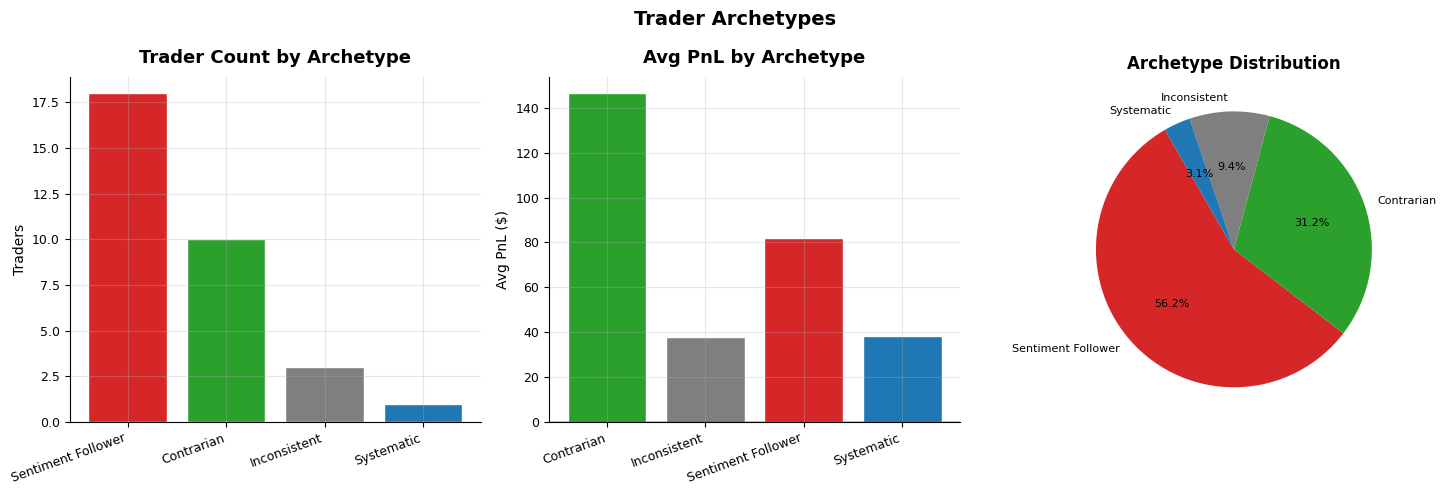

In [3]:
if 'archetype' in trader_profile.columns:
    arch_counts = trader_profile['archetype'].value_counts()
    arch_pnl    = trader_profile.groupby('archetype')['avg_pnl'].mean()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    arch_colors = {
        'Contrarian':         '#2ca02c',
        'Systematic':         '#1f77b4',
        'Sentiment Follower': '#d62728',
        'Inconsistent':       '#7f7f7f',
        'Insufficient Data':  '#c7c7c7',
    }
    clrs = [arch_colors.get(a, '#999') for a in arch_counts.index]

    # Counts
    axes[0].bar(arch_counts.index, arch_counts.values, color=clrs, edgecolor='white')
    plt.setp(axes[0].get_xticklabels(), rotation=20, ha='right')
    style_axes(axes[0], 'Trader Count by Archetype', '', 'Traders')

    # Avg PnL
    clrs2 = [arch_colors.get(a, '#999') for a in arch_pnl.index]
    axes[1].bar(arch_pnl.index, arch_pnl.values, color=clrs2, edgecolor='white')
    axes[1].axhline(0, color='black', lw=1)
    plt.setp(axes[1].get_xticklabels(), rotation=20, ha='right')
    style_axes(axes[1], 'Avg PnL by Archetype', '', 'Avg PnL ($)')

    # Pie
    axes[2].pie(arch_counts, labels=arch_counts.index, colors=clrs,
                autopct='%1.1f%%', startangle=120, textprops={'fontsize':8})
    axes[2].set_title('Archetype Distribution', fontweight='bold')

    plt.suptitle('Trader Archetypes', fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_fig('10_trader_archetypes')
    plt.show()


## 4B — Sentiment Transition Effects
Does the zone on yesterday, or a recent streak, predict today's performance?

Daily rows : 479
FGI nulls  : 0
      date  fgi_score    avg_pnl
2023-05-01       63.0   0.000000
2023-12-05       75.0   0.000000
2023-12-14       72.0 -18.675885
2023-12-15       70.0 -12.316017
2023-12-16       67.0   0.000000
2023-12-17       73.0  21.784485
2023-12-18       65.0   0.000000
2023-12-19       73.0  66.702574
2023-12-20       74.0   9.040682
2023-12-21       70.0  10.963498
Saved -> C:\project\trading_sentiment_project\outputs\charts\11_fgi_vs_pnl_fixed.png


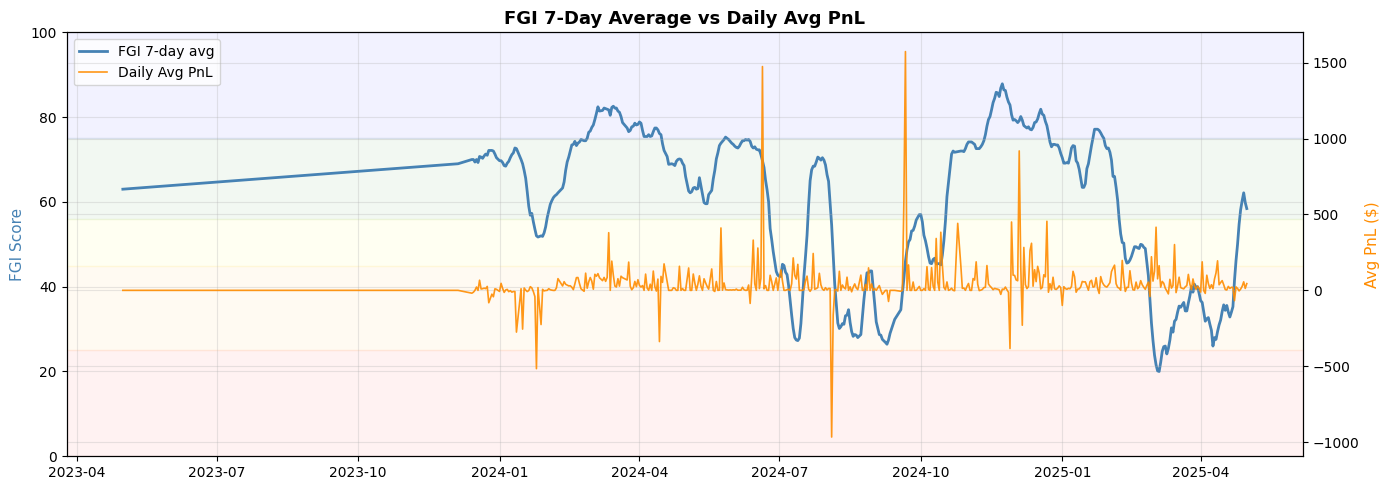

In [4]:
if "closedPnL" in analysis.columns:
    daily = (
        analysis.groupby("date")
                .agg(
                    avg_pnl=("closedPnL", "mean"),
                    win_rate=("closedPnL", lambda x: (x > 0).mean()),
                    fgi_score=("fgi_score", "first"),
                    zone=("classification", "first"),
                )
                .reset_index()
                .sort_values("date")
    )

    daily["fgi_7d_avg"] = daily["fgi_score"].rolling(7, min_periods=1).mean()

    print(f"Daily rows : {len(daily)}")
    print(f"FGI nulls  : {daily['fgi_score'].isna().sum()}")
    print(daily[["date", "fgi_score", "avg_pnl"]].head(10).to_string(index=False))

    fig, ax = plt.subplots(figsize=(14, 5))
    ax2 = ax.twinx()

    ax.plot(daily["date"], daily["fgi_7d_avg"], color="steelblue", lw=2, label="FGI 7-day avg")
    ax2.plot(daily["date"], daily["avg_pnl"], color="darkorange", lw=1.2, alpha=0.9, label="Daily Avg PnL")

    ax.axhspan(0, 25, alpha=0.05, color="red")
    ax.axhspan(25, 45, alpha=0.05, color="orange")
    ax.axhspan(45, 56, alpha=0.05, color="yellow")
    ax.axhspan(56, 75, alpha=0.05, color="green")
    ax.axhspan(75, 100, alpha=0.05, color="blue")

    ax.set_ylim(0, 100)
    ax.set_ylabel("FGI Score", color="steelblue", fontsize=11)
    ax2.set_ylabel("Avg PnL ($)", color="darkorange", fontsize=11)
    ax.set_title("FGI 7-Day Average vs Daily Avg PnL", fontsize=13, fontweight="bold")

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    plt.tight_layout()
    save_fig("11_fgi_vs_pnl_fixed")
    plt.show()


## 4C — Leverage Discipline: Win Rate by Leverage Bucket × Zone

In [5]:
if "leverage" in analysis.columns and analysis["leverage"].notna().sum() > 0:
    data = analysis[analysis["leverage"].notna()].copy()
    bins = [0, 3, 5, 10, 20, 200]
    labels = ["1-3x", "3-5x", "5-10x", "10-20x", "20x+"]
    data["lev_bucket"] = pd.cut(data["leverage"], bins=bins, labels=labels)

    pivot = (
        data.groupby(["classification", "lev_bucket"], observed=False)["closedPnL"]
            .apply(lambda x: round((x > 0).mean() * 100, 1))
            .unstack("lev_bucket")
            .reindex(ZONE_ORDER)
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".0f",
        cmap="RdYlGn",
        vmin=30,
        vmax=70,
        linewidths=0.5,
        ax=ax,
        cbar_kws={"label": "Win Rate (%)"},
    )
    style_axes(ax, "Win Rate (%) - Sentiment Zone x Leverage Bucket", "", "")
    plt.tight_layout()
    save_fig("12_leverage_zone_winrate_heatmap")
    plt.show()

    print("Key takeaway: check which leverage+zone combo has the highest win rate")
    best = pivot.stack().idxmax()
    worst = pivot.stack().idxmin()
    print(f"  Best combo : Zone={best[0]}, Leverage={best[1]}")
    print(f"  Worst combo: Zone={worst[0]}, Leverage={worst[1]}")
else:
    print("Leverage analysis skipped because the trades CSV has no leverage column.")


Leverage analysis skipped because the trades CSV has no leverage column.


## 4D — Final Summary Report

In [6]:
print("\n" + "=" * 60)
print("  FINAL SUMMARY REPORT")
print("=" * 60)

if "closedPnL" in analysis.columns:
    closed = analysis.copy()
    zone_stats = (
        closed.groupby("classification", observed=False)["closedPnL"]
              .agg(["mean", "count", lambda x: (x > 0).mean()])
              .reindex(ZONE_ORDER)
    )
    zone_stats.columns = ["Avg PnL", "Trades", "Win Rate"]
    zone_stats["Win Rate"] = (zone_stats["Win Rate"] * 100).round(1)

    best_zone = zone_stats["Avg PnL"].idxmax()
    worst_zone = zone_stats["Avg PnL"].idxmin()
    best_wr = zone_stats["Win Rate"].idxmax()

    print("\nZone Performance:")
    print(zone_stats.to_string())
    print(f"\nBest avg PnL zone     : {best_zone} (${zone_stats.loc[best_zone, 'Avg PnL']:.2f}/trade)")
    print(f"Worst avg PnL zone    : {worst_zone} (${zone_stats.loc[worst_zone, 'Avg PnL']:.2f}/trade)")
    print(f"Highest win rate zone : {best_wr} ({zone_stats.loc[best_wr, 'Win Rate']:.1f}%)")

    if "leverage" in closed.columns and closed["leverage"].notna().sum() > 0:
        avg_lev_zone = closed.groupby("classification", observed=False)["leverage"].mean().reindex(ZONE_ORDER)
        riskiest_zone = avg_lev_zone.idxmax()
        print(f"Highest avg leverage  : {riskiest_zone} ({avg_lev_zone[riskiest_zone]:.1f}x)")

print("\nDATA-DRIVEN TAKEAWAYS:")
if "closedPnL" in analysis.columns:
    print(f"  1. {best_zone} has the highest average PnL per trade in the matched sentiment dataset.")
    print(f"  2. {best_wr} has the highest win rate at {zone_stats.loc[best_wr, 'Win Rate']:.1f}%.")

if "arch_summary" in globals() and not arch_summary.empty:
    top_arch = arch_summary["avg_pnl"].idxmax()
    print(f"  3. {top_arch} traders have the highest average PnL in this sample.")
else:
    print("  3. Archetype summary is unavailable until the earlier cells are run.")

if "has_sentiment" in merged.columns and (~merged["has_sentiment"]).any():
    missing_dates = sorted(
        merged.loc[~merged["has_sentiment"], "date"]
              .dropna()
              .dt.strftime("%Y-%m-%d")
              .unique()
              .tolist()
    )
    print(
        f"  4. Zone-based analysis excludes {int((~merged['has_sentiment']).sum()):,} rows "
        f"because FGI is missing for: {', '.join(missing_dates)}."
    )
else:
    print("  4. Every cleaned trade row has a sentiment match.")

if "leverage" in analysis.columns and analysis["leverage"].notna().sum() > 0:
    print("  5. Leverage-specific charts are included because leverage exists in the raw trades CSV.")
else:
    print("  5. Leverage-specific analysis was skipped because the raw trades CSV has no leverage column.")

print("\nAll charts saved to: outputs/charts/")
print("All reports saved to: outputs/reports/")



  FINAL SUMMARY REPORT

Zone Performance:
                  Avg PnL  Trades  Win Rate
classification                             
Extreme Fear    34.537862   21400      37.1
Fear            54.290400   61837      42.1
Neutral         34.307718   37686      39.7
Greed           42.743559   50303      38.5
Extreme Greed   67.892861   39992      46.5

Best avg PnL zone     : Extreme Greed ($67.89/trade)
Worst avg PnL zone    : Neutral ($34.31/trade)
Highest win rate zone : Extreme Greed (46.5%)

DATA-DRIVEN TAKEAWAYS:
  1. Extreme Greed has the highest average PnL per trade in the matched sentiment dataset.
  2. Extreme Greed has the highest win rate at 46.5%.
  3. Contrarian traders have the highest average PnL in this sample.
  4. Zone-based analysis excludes 6 rows because FGI is missing for: 2024-10-26.
  5. Leverage-specific analysis was skipped because the raw trades CSV has no leverage column.

All charts saved to: outputs/charts/
All reports saved to: outputs/reports/


In [7]:
if "closedPnL" in analysis.columns:
    agg_map = {
        "trade_count": ("closedPnL", "count"),
        "avg_pnl": ("closedPnL", "mean"),
        "median_pnl": ("closedPnL", "median"),
        "total_pnl": ("closedPnL", "sum"),
        "win_rate": ("closedPnL", lambda x: (x > 0).mean()),
    }
    if "leverage" in analysis.columns:
        agg_map["avg_leverage"] = ("leverage", "mean")

    report = (
        analysis.groupby("classification", observed=False)
                .agg(**agg_map)
                .reindex(ZONE_ORDER)
                .round(3)
    )
    report.to_csv(REPORTS_DIR / "zone_performance_report.csv")
    print("Saved zone_performance_report.csv")


Saved zone_performance_report.csv
